In [1]:
# Residency Week Project
## Deliverable 2: Regression Modeling and Performance Evaluation

# Bilal Khalid
# Advanced Big Data and Data Mining (MSCS-634-M20)
# Online Shoppers Purchasing Intention dataset

In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load Dataset

df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [7]:
# Dataset Overview
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 12330
Columns : 18


In [8]:
# Missing Values Analysis
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [9]:
# Duplicate Records Analysis
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 125


In [10]:
# Data Cleaning
df = df.drop_duplicates()

print(df.shape)

(12205, 18)


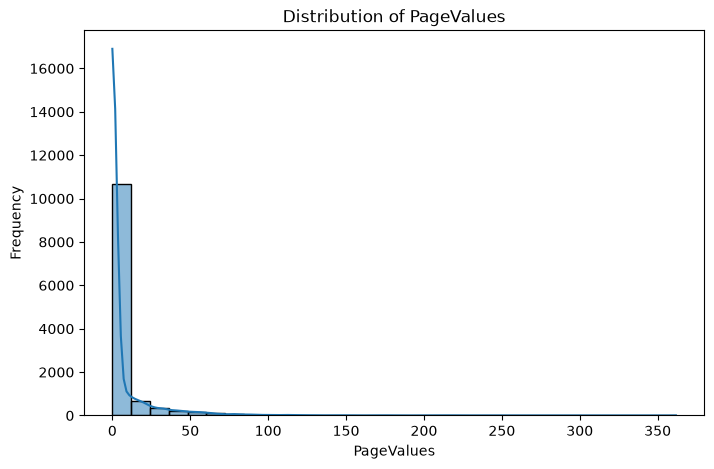

In [3]:
# Distribution of PageValues

plt.figure(figsize=(8,5))

sns.histplot(
    df["PageValues"],
    bins=30,
    kde=True
)

plt.title("Distribution of PageValues")

plt.xlabel("PageValues")

plt.ylabel("Frequency")

plt.show()

In [4]:
print(df.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [5]:
# One-Hot Encoding

df_encoded = pd.get_dummies(

    df,

    columns=[
        "Month",
        "VisitorType"
    ],

    drop_first=True
)

In [6]:
# Convert Boolean values into integers

df_encoded["Weekend"] = df_encoded["Weekend"].astype(int)

df_encoded["Revenue"] = df_encoded["Revenue"].astype(int)

In [7]:
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [8]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [9]:
# Separate Features and Target

X = df_encoded.drop("PageValues", axis=1)

y = df_encoded["PageValues"]

In [10]:
print("Feature Matrix Shape")

print(X.shape)

print()

print("Target Shape")

print(y.shape)

Feature Matrix Shape
(12330, 26)

Target Shape
(12330,)


In [11]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [12]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (9864, 26)
Testing Features : (2466, 26)

Training Target : (9864,)
Testing Target : (2466,)


In [13]:
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
1785,0,0.0,0,0.0,7,95.000000,0.014286,0.061905,0.0,2,...,False,False,False,True,False,False,False,False,False,True
10407,2,14.0,0,0.0,81,1441.910588,0.002469,0.013933,0.0,2,...,False,False,False,False,False,True,False,False,False,True
286,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,2,...,False,False,False,True,False,False,False,False,False,True
6520,5,49.2,4,379.0,5,74.600000,0.000000,0.018182,0.0,2,...,False,False,False,False,False,False,False,True,False,False
12251,0,0.0,1,5.0,9,279.000000,0.040000,0.041667,0.0,3,...,False,False,False,False,False,True,False,False,False,False


In [14]:
# Linear Regression Model

# Create the Linear Regression model

linear_model = LinearRegression()

# Train the model using the training dataset

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [15]:
# Predict PageValues using the trained model

# Predict values for the testing dataset

y_pred_linear = linear_model.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


In [16]:
# Compare Actual and Predicted values

comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred_linear

})

comparison.head(10)

,Actual,Predicted
0,0.000000,3.493392
1,2.086218,27.868338
2,3.451072,0.065707
3,36.672294,2.802461
4,10.150644,2.043641
5,0.000000,1.572387
6,0.000000,2.259706
7,0.000000,-1.505431
8,48.729956,5.184447
9,0.000000,7.416486


In [17]:
comparison.head(10)

,Actual,Predicted
0,0.000000,3.493392
1,2.086218,27.868338
2,3.451072,0.065707
3,36.672294,2.802461
4,10.150644,2.043641
5,0.000000,1.572387
6,0.000000,2.259706
7,0.000000,-1.505431
8,48.729956,5.184447
9,0.000000,7.416486


In [18]:
# Calculate Evaluation Metrics

# Mean Absolute Error

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

# Mean Squared Error

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

# Root Mean Squared Error

rmse_linear = np.sqrt(mse_linear)

# R-Squared Score

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")

print("-"*40)

print("MAE  :", round(mae_linear,2))

print("MSE  :", round(mse_linear,2))

print("RMSE :", round(rmse_linear,2))

print("R²   :", round(r2_linear,4))

Linear Regression Performance
----------------------------------------
MAE  : 7.25
MSE  : 269.91
RMSE : 16.43
R²   : 0.2446


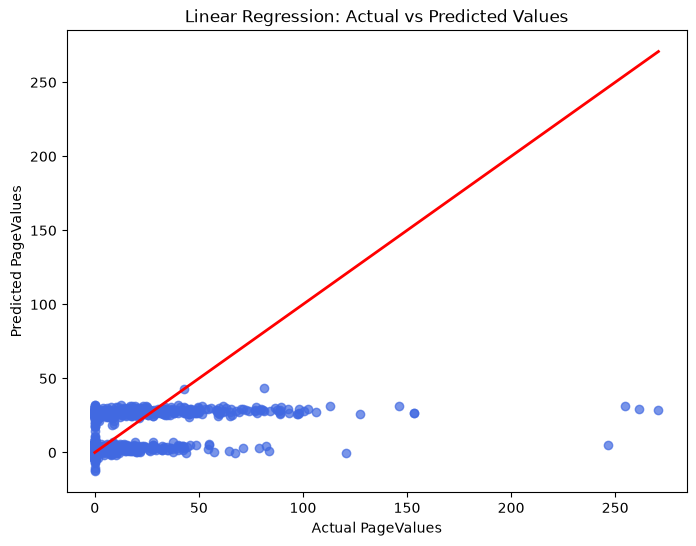

In [19]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred_linear,

    color="royalblue",

    alpha=0.7

)

# Perfect prediction line

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.title("Linear Regression: Actual vs Predicted Values")

plt.xlabel("Actual PageValues")

plt.ylabel("Predicted PageValues")

plt.show()

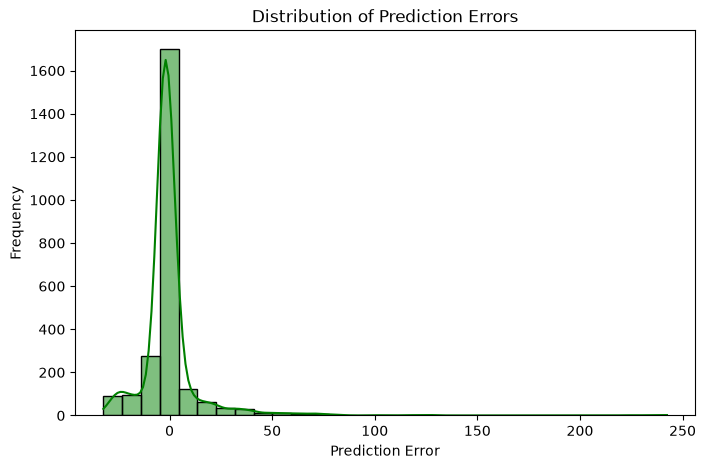

In [20]:
# Residual Plot

errors = y_test - y_pred_linear

plt.figure(figsize=(8,5))

sns.histplot(

    errors,

    bins=30,

    kde=True,

    color="green"

)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

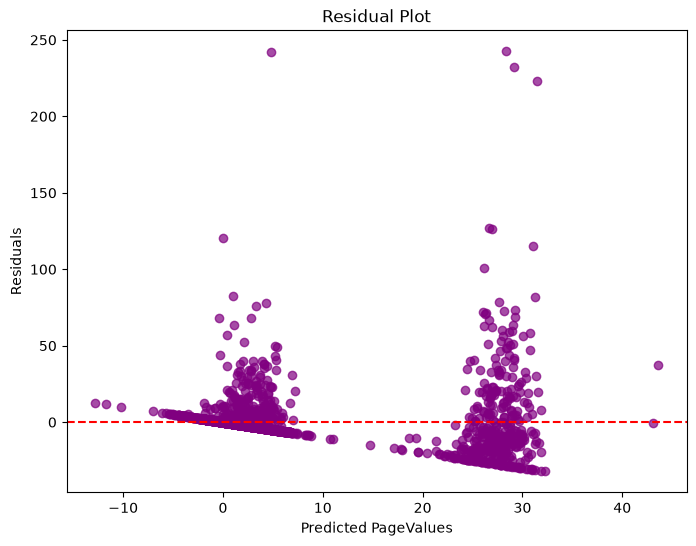

In [21]:
# Residual Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(

    y_pred_linear,

    errors,

    alpha=0.7,

    color="purple"

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Predicted PageValues")

plt.ylabel("Residuals")

plt.show()

In [22]:
linear_results = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R²"

    ],

    "Value":[

        mae_linear,

        mse_linear,

        rmse_linear,

        r2_linear

    ]

})

linear_results

,Metric,Value
0,MAE,7.247236
1,MSE,269.905529
2,RMSE,16.428802
3,R²,0.244605
